# Introduction

<div class="alert alert-warning">     
<b> Table of Contents </b>

1. [Introduction](#introduction)
2. [Linear Regression](#lir)
3. [Logistic Regression](#lr)
4. [SVM](#svm)
5. [Exercise](#exercise)

<div class="alert alert-warning">
    <b> I. <i>Introduction </i></b>
    <a id="introduction"></a></div>

Machine Learning models often aim to learn patterns from data in order to make predictions. Depending on the type of problem, we use different approaches. In this section, we introduce three fundamental supervised learning models: Linear Regression, Logistic Regression, and Support Vector Machines (SVM).  

These models share a common idea: they all try to find a decision boundary that best separates or predicts outcomes based on input features.

We will import the libraries: 

In [32]:
import numpy as np
import matplotlib.pyplot as plt

We will use also ``scikit-learn``. This library is one of the most popular Python libraries for Machine Learning. It provides simple tools to train models, make predictions, evaluate performance or split datasets. 



In [33]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVC

In this notebook, we will import different algorithms. Initially, we will work with Linear Regression, then with Logistic Regression and SVM (Support Vector Machines).

``FIRST STEP: PREPARE THE DATA``

Before training any machine learning model, the most important step is preparing the data.
We first separate the dataset into:
- Inputs (X) → the features used to make predictions
- Targets (y) → the correct answers we want the model to learn. 

For example, predict house price. Our X is size, location and rooms and y is the price. 

``SECOND STEP: SPLIT THE DATA``

After defining X and y, we divide the dataset into two parts:

- Training set → used to train the model
- Test set → used to evaluate how well the model performs on new data

This is important because we want to check if the model can generalize, not just memorize the data.

``THIRD STEP: TRAIN MODEL`` 

We train a machine learning algorithm using our training data and then evaluate the performance on test set. 

``FOURTH STEP: HOW WE MEASURE THE PERFORMANCE? ``

We use error metrics to see how far predictions are from real values:

_1. Mean Absolute Error (MAE)_

MAE measures the average absolute difference between predicted and real values.

MAE = (1/n) * Σ |y - ŷ|

_2. Mean Squared Error (MSE)_

MSE measures the average squared error, penalizing large mistakes more.

MSE = (1/n) * Σ (y - ŷ)²

_3. Accuracy score_
Measures how often the model is correct overall. It can be misleading if classes are imbalanced.

$ Accuracy = \frac{\text{Number of correct predictions}}{\text{Total number of predictions}}$

_4. Confusion matrix_ 

A confusion matrix is a tool used to evaluate the performance of a classification model. It provides a visual representation of how the model has classified the data, showing the correspondence between the true labels and the predictions made by the model.

It is a table that generally has the following characteristics:

The rows represent the actual classes (correct labels).

The columns represent the classes predicted by the model.

It is especially useful in situations where the classes are imbalanced, as it allows identifying potential biases of the model.

_5. Classification report._

A summary of key performance metrics per class:

- $ Precision = \frac{\text{True Positives}}{\text{True Positives + False Positives}}$
- $ Recall = \frac{\text{True Positives}}{\text{True Positives + False Negatives}} $
- $ F1 Score = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$

`See more`: [Classification metrics](https://scikit-learn.org/stable/api/sklearn.metrics.html#classification-metrics)

We import the following: 

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, confusion_matrix, classification_report

<div class="alert alert-warning">
    <b> II. <i>Linear Regression </i></b>
    <a id="lir"></a></div>

The linear regression model is a simple yet powerful technique for regression problems, aiming to find the linear relationship between a dependent variable and one or more independent variables. This model assumes that there is a direct connection between the variables, expressed as a straight line in the case of one independent variable (simple linear regression), or as a hyperplane in higher-dimensional spaces (multiple linear regression).

Its main function is to approximate the data using a linear function, minimizing the sum of squared errors between the model’s predictions and the actual observed values. This is done, as you’ve seen in theory, using the least squares method, which adjusts the coefficients of the line to best fit the data points.

y = $w_0$ + $w_1$ * x

Where $w_0$ is the bias or intercept, and  $w_1$ is the coefficient of the independent variable.

We will start using this dataset: 

In [35]:
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()
X = data.data
y = data.target

I am going to use a subset: 

In [36]:
idx = np.random.choice(len(X), 800, replace=False)

X = X[idx]
y = y[idx]

We can plot to see how is this data.

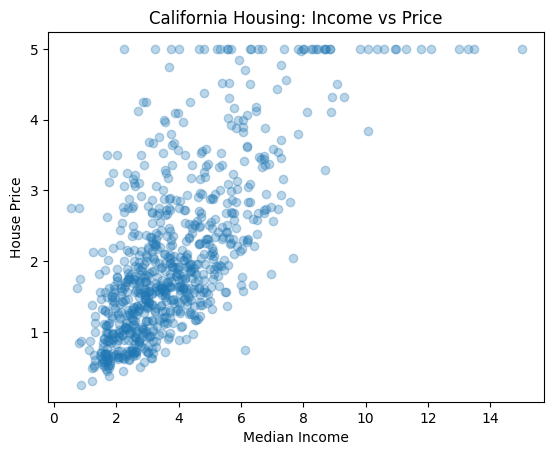

In [37]:
X_medinc = X[:, 0] # I only plot one feature of the data
plt.scatter(X_medinc, y, alpha=0.3)
plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.title("California Housing: Income vs Price")
plt.show()

Now, we divide the dataset into training and test. The function `train_test_split` splits the dataset into training and test sets. It takes as input the features and target variable. We difine the proportion of data used for testing with ``test_size`` and select a random seed for reproducibility with ``random_state``

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X[:,0].reshape(-1, 1), y, test_size=0.20, random_state=42
)

We are creating an object from the Linear Regression model provided by ``scikit-learn``. This object will later be used to:

- Learn the relationship between input data (X) and output (y)
- Predict new values
- Estimate the best fitting line

The parameter ``fit_intercept`` controls whether the model should compute the intercept (bias term) automatically. The intercept is the value of the model when all input features are 0.

To train the model we use ``fit``

In [39]:
model = LinearRegression(fit_intercept=True)
model.fit(X_train, y_train)


LinearRegression()

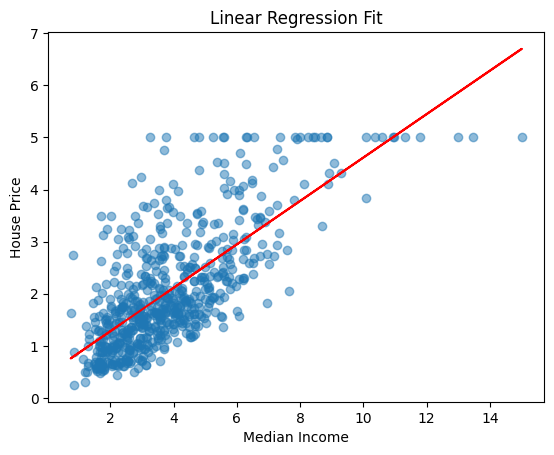

In [40]:
y_line = model.predict(X_train)

plt.scatter(X_train, y_train, alpha=0.5)
plt.plot(X_train, y_line, color="red")

plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.title("Linear Regression Fit")
plt.show()



Now, we can test the model with our test set. We use `predict` to make predictions

In [41]:
y_pred= model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)

MAE: 0.6736289909744728
MSE: 0.8186999107025494


<div class="alert alert-warning">
    <b> III. <i>Logistic Regression </i></b>
    <a id="lr"></a></div>

Logistic regression is a statistical and machine learning technique primarily used for binary classification tasks, although it can also be generalized to multiple categories. Its goal is to model the probability that an observation belongs to a specific class based on a set of predictive variables (also known as features or attributes).

Unlike linear regression, which predicts continuous values, logistic regression predicts a probability — a value between 0 and 1. To achieve this, it uses a sigmoid or logistic function, which transforms any input (which can range from −∞ to ∞ ) into a value within this interval.

I am going to use the iris dataset: 

In [42]:
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data
y = (iris.target == 0).astype(int) # this line set 1 if is setosa, and 0 if not.

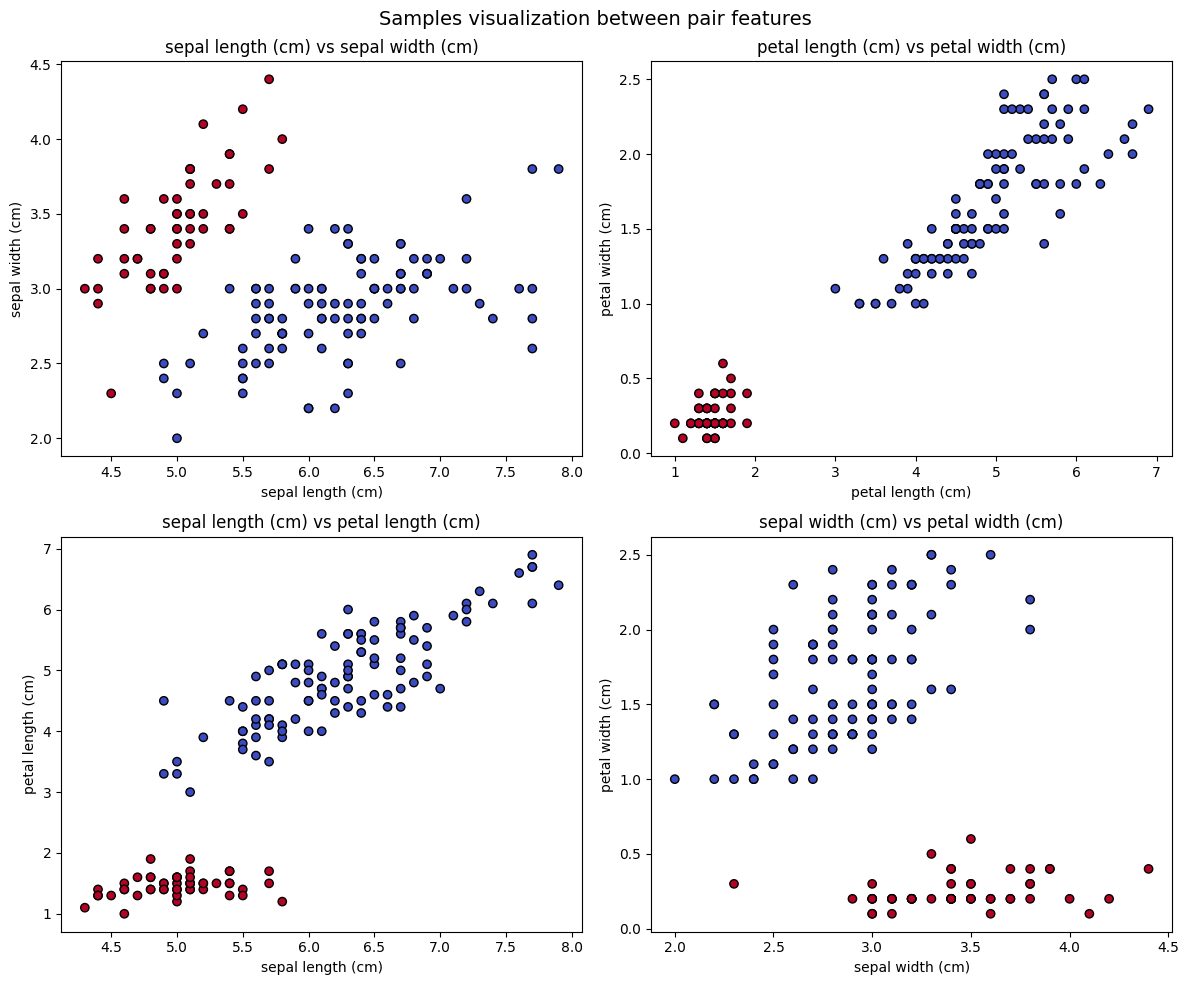

In [43]:
feature_names = iris.feature_names
combinations = [(0, 1), (2, 3), (0, 2), (1, 3)]  # 4 pares de características

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (f1, f2) in enumerate(combinations):
    X_pair = X[:, [f1, f2]]
    ax = axes[i]
    ax.scatter(X_pair[:, 0], X_pair[:, 1], c=y, cmap='coolwarm', edgecolors='k')
    ax.set_title(f'{feature_names[f1]} vs {feature_names[f2]}')
    ax.set_xlabel(feature_names[f1])
    ax.set_ylabel(feature_names[f2])

plt.suptitle("Samples visualization between pair features", fontsize=14)
plt.tight_layout()
plt.show()

We are going to use the first and second feature: 

In [44]:
X =  X[:, :2]

<div class="alert alert-info">

_Mini Activity_

Divide the data into train and test

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
   X , y, test_size=0.20, random_state=42
)

Let's create a Logistic Regression model. We can indicate the following parameters: 

``penalty`` : Controls regularization type (how the model avoids overfitting):
- 'l2' → default, most common (smooth weights)
- 'l1' → makes some features exactly 0 (feature selection)
- 'elasticnet' → mix of L1 + L2
- None → no regularization (rare, can overfit)

_What is overfitting?_ Overfitting happens when a model learns the training data too well, including noise and random patterns, instead of learning the general underlying structure.

``C``: Controls regularization strength
- Small C → strong regularization (simpler model)
- Large C → weak regularization (fits data more closely)
- C = np.inf → no regularization

``max_iter``: Maximum training iterations.

``class_weight``: Handles imbalanced datasets. If set to ``balanced`` automatically adjusts weights. Class weights are used when dataset has imbalanced classes (one class appears much more than another). They tell the model to pay attention to the rare class so mistakes on the minority class are penalized more. 


In [46]:
model = LogisticRegression()

<div class="alert alert-info">

_Mini Activity_

Train the model using `fit` and predict the test set using `predict`

In [47]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

Let's evaluate the model. We are going to use the classification report function.

In [48]:
print("\nReport:\n", classification_report(y_test, y_pred))


Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Let's also visualize the confusion matrix: 

<Axes: >

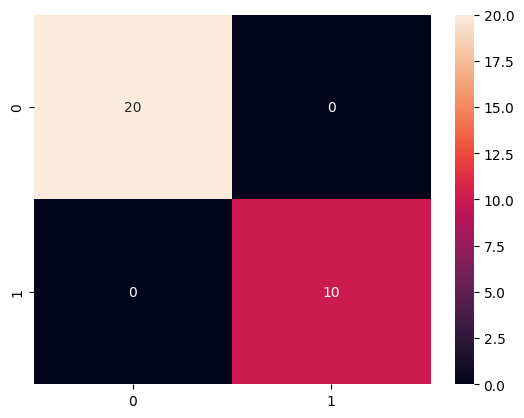

In [49]:
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True)

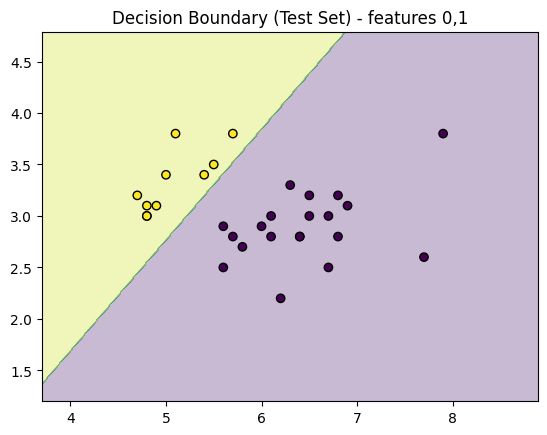

In [50]:
def plot_decision_regions_test_only(X_test, y_test, model, feature_indices=(0, 1)):
    f1, f2 = feature_indices

    x_min, x_max = X_test[:, f1].min() - 1, X_test[:, f1].max() + 1
    y_min, y_max = X_test[:, f2].min() - 1, X_test[:, f2].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.01),
        np.arange(y_min, y_max, 0.01)
    )

    X_grid = np.zeros((xx.ravel().shape[0], X_test.shape[1]))

    X_grid[:, f1] = xx.ravel()
    X_grid[:, f2] = yy.ravel()

    # fill other features with mean values
    for i in range(X_test.shape[1]):
        if i != f1 and i != f2:
            X_grid[:, i] = np.mean(X_test[:, i])

    Z = model.predict(X_grid).reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X_test[:, f1], X_test[:, f2], c=y_test, edgecolor='k')
    plt.title(f"Decision Boundary (Test Set) - features {f1},{f2}")
    plt.show()

plot_decision_regions_test_only(X_test, y_test, model)

<div class="alert alert-warning">
    <b> IV. <i>SVM </i></b>
    <a id="svm"></a></div>

A Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification (and also regression). It tries to find the best possible boundary (hyperplane) that separates classes with the maximum margin.

If we have two groups of points in a 2D space, SVM chooses one line that separates the classes correctly, leaves the largest possible margin between them and uses only the most important points, called support vectors. Those support vectors are the points closest to the decision boundary.

The most important parameters: 
- ``C``: This is the regularization parameters which controls the trade-off between maximizing margin and minimizing classification error. 
    - We can put an small C (0.01), allowing the model to have more margin and tolerance to error, which may underfit. 
    - We can put a large C (100), can overfit as makes a hard classification of training data. 
- ``Kernel`` defines how the data is transformed: 

| Kernel     | Meaning                     | When to use                          |
|------------|----------------------------|--------------------------------------|
| linear     | Straight line boundary     | Data is linearly separable           |
| rbf        | Radial basis function      | Non-linear patterns                  |
| poly       | Polynomial boundary        | Curved or structured data            |

Depending on the kernel, we have specific parameters: 
- `gamma`: This is only used with rbf kernel. Using a low gamm makes a simpler and smooth boundary, while a high gamma makes a more tight boundary and we risk of overfitting. 
- `degree`: This is only used in polynomial kernel. It controls the complexity of the polinomial boundary. With a low degree computes a simple curve, with a high degree we can risk of overfitting. 
- `coef0`: 

<div class="alert alert-info">

_Mini Activity_

Can you try different kernels, C and other parameters? 

In [51]:
model = SVC(kernel='linear', C=1)
model.fit(X_train, y_train)

SVC(C=1, kernel='linear')

In [52]:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [53]:
def plot_svm_decision_boundary(model, X, y, titol=None):
    if titol is None:
        titol = "Decision Regions"

    # Crear un meshgrid
    xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 500),
                         np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 500))
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Dibuixar l'hiperplà i els marges
    plt.contourf(xx, yy, Z > 0, alpha=0.6, cmap='coolwarm')
    plt.contour(xx, yy, Z, levels=[-1, 0, 1], colors=['blue', 'black', 'red'],
                linestyles=['--', '-', '--'])
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k')
    plt.title(titol)
    plt.show()

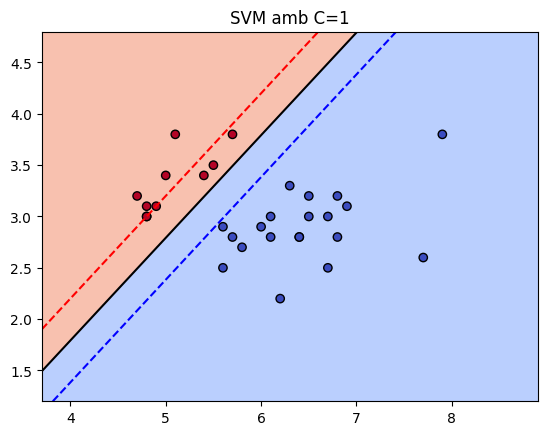

In [54]:
plot_svm_decision_boundary(model, X_test, y_test, f"SVM amb C=1")

<div class="alert alert-warning">
    <b> V. <i>Exercise </i></b>
    <a id="exercise"></a></div>

<div class="alert alert-info">

_Linear Regression_

We will use the Global Sea levels dataset from NASA. This dataset tracks sea level change since 1993 using satellite data.

In [55]:
import pandas as pd
df = pd.read_csv("sealevel.csv")
df.head()

,Year,TotalWeightedObservations,GMSL_noGIA,StdDevGMSL_noGIA,SmoothedGSML_noGIA,GMSL_GIA,StdDevGMSL_GIA,SmoothedGSML_GIA,SmoothedGSML_GIA_sigremoved
0,1993,327401.31,-38.59,89.86,-38.76,-38.59,89.86,-38.75,-38.57
1,1993,324498.41,-41.97,90.86,-39.78,-41.97,90.86,-39.77,-39.11
2,1993,333018.19,-41.93,87.27,-39.62,-41.91,87.27,-39.61,-38.58
3,1993,297483.19,-42.67,90.75,-39.67,-42.65,90.74,-39.64,-38.34
4,1993,321635.81,-37.86,90.26,-38.75,-37.83,90.25,-38.72,-37.21


We will use only one feature to make it simple.

In [56]:
X = df[["Year"]]  # use only 1 feature
y = df["SmoothedGSML_GIA_sigremoved"]

Split the data: 

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

__Task 1__

Create and train a model. 

In [58]:
model = LinearRegression(fit_intercept=True)
model.fit(X_train, y_train)

LinearRegression()

__Task 2__

Make predictions, check the parameters and evaluate the model using MAE and MSE. 

In [59]:
model.coef_

array([3.36290984])

In [60]:
model.intercept_

-6740.304016907306

In [61]:
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"Mean absolute error:{mae}")
print(f"Mean squared error:{mse} ")

Mean absolute error:3.3455175968492052
Mean squared error:16.906226132619857 


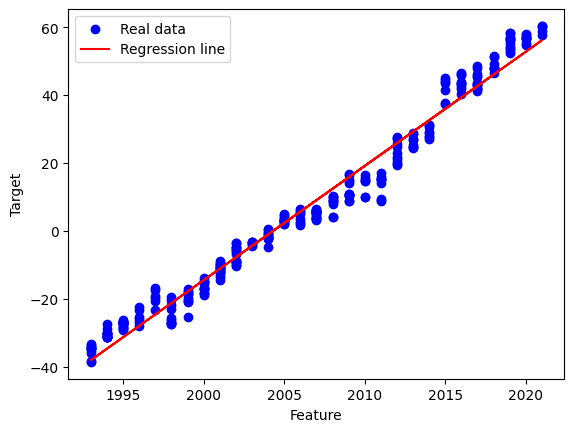

In [62]:
plt.scatter(X_test, y_test, color="blue", label="Real data")
plt.plot(X_test, y_pred, color="red", label="Regression line")

plt.xlabel("Feature")
plt.ylabel("Target")
plt.legend()
plt.show()